# Palmer Archipelago Dataset Hypothesis Tests

## Description

This dataset contains **morphological measurements of penguins** collected in the **Palmer Archipelago, Antarctica**.
It’s often used as an educational dataset in data science as a more interesting substitute for the classic *iris* dataset.  
The data were collected from **three penguin species** during field studies conducted between **2007 and 2009** by the Palmer Station Long Term Ecological Research (LTER) program.  

Rows typically represent individual penguin observations with measurements of body size and other features.

| Column Name            | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| `species`              | Penguin species (e.g., Adelie, Chinstrap, Gentoo). Categorical label.      |
| `island`               | Island in the Palmer Archipelago where the penguin was observed (Biscoe, Dream, Torgersen). |
| `culmen_length_mm`     | Length of the penguin’s bill (culmen) in millimeters.                       |
| `culmen_depth_mm`      | Depth (height) of the penguin’s bill in millimeters.                        |
| `flipper_length_mm`    | Length of the penguin’s flippers in millimeters.                             |
| `body_mass_g`          | Body mass (weight) of the penguin in grams.                                  |
| `sex`                  | Penguin’s sex (male or female). May contain missing values (NA).             |
| `year`                 | Year the observation was recorded (typically 2007, 2008, or 2009).

## In this dataset, the following statistical techniques were used:

### Hypothesis Tests
- _One-way ANOVA_
- _Shapiro-Wilk test_ (goodness-of-fit, $W$)
- _Bartlett's test_
- _Levene's test_
- _Tukey's HSD_ (post-hoc)
- _Chi-square test of independence_ ($\chi^2$)
- _t-test_

### Correlations and Measures of Association
- _Spearman's rank correlation coefficient_ ($\rho$)
- _Pearson correlation coefficient_ ($r$)
- _Cramér's V_ ($V$)
- _Phi coefficient_ ($\phi$)
- _Pearson's contingency coefficient (C)_ ($C$)

## Libraries import

In [106]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from bioinfokit.analys import stat

## Dataset import

In [107]:
kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data", output_dir="data", force_download=True)

100%|██████████| 11.3k/11.3k [00:00<00:00, 5.80MB/s]

Extracting files...


'data'

In [108]:
df = pd.read_csv('data/penguins_lter.csv')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [110]:
df.sample(5)

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
53,PAL0809,54,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N22A2,Yes,11/9/08,42.0,19.5,200.0,4050.0,MALE,8.48095,-26.31460,NaN
26,PAL0708,27,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N17A1,Yes,11/12/07,40.6,18.6,183.0,3550.0,MALE,8.93997,-25.36288,NaN
39,PAL0708,40,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N25A2,No,11/13/07,39.8,19.1,184.0,4650.0,MALE,NaN,NaN,Nest never observed with full clutch. Not enou...
93,PAL0809,94,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N46A2,Yes,11/5/08,39.6,18.1,186.0,4450.0,MALE,8.49915,-26.42406,NaN
9,PAL0708,10,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A2,Yes,11/9/07,42.0,20.2,190.0,4250.0,NaN,9.13362,-25.09368,No blood sample obtained for sexing.


Drop null data

In [111]:
df.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64

In [112]:
df = df.dropna(subset=[col for col in df.columns if col != 'Comments'])

In [113]:
df.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       0
Culmen Depth (mm)        0
Flipper Length (mm)      0
Body Mass (g)            0
Sex                      0
Delta 15 N (o/oo)        0
Delta 13 C (o/oo)        0
Comments               312
dtype: int64

## Hypothesis Test #1 - One-way ANOVA

### Body Mass (g) Differences Between Penguin Species (Numerical Variable Across Groups)

**One-way ANOVA** is a statistical test used to determine whether there are **significant differences between the means of three or more independent groups**.
It is commonly applied when you have **one numerical dependent variable** and **one categorical independent variable** (factor) with multiple levels.

### Hypotheses

- $H_0$: All group means are equal ($\mu_1 = \mu_2 = \dots = \mu_k$)
- $H_1$: At least one group mean is different

### Test Statistic

The ANOVA test statistic is the **F-ratio**, calculated as:

$$
F = \frac{MS_{between}}{MS_{within}}
$$

Where:

- $MS_{between}$ – mean square **between groups**
- $MS_{within}$ – mean square **within groups** (error/residual)

The F-ratio measures how much the group means **differ relative to the variability within groups**.

### Assumptions

To validly perform a one-way ANOVA, the following assumptions should be met:

1. **Independence of observations** – each observation is independent of the others
2. **Normality** – the dependent variable should be approximately normally distributed in each group
   - Can be tested using the **Shapiro-Wilk test**
3. **Homoscedasticity (equal variances)** – the variance of the dependent variable should be similar across groups
   - Can be tested using **Bartlett’s test** or **Levene’s test**

### Decision Rule

- Calculate the **F statistic**
- Compare it with the **critical value** from the F-distribution with degrees of freedom $(k-1, n-k)$, where:
  - $k$ = number of groups
  - $n$ = total number of observations
- Alternatively, compare the **p-value** to the chosen significance level $\alpha$

- If $p < \alpha$, reject $H_0$ → **at least one group mean is significantly different**
- If $p \geq \alpha$, fail to reject $H_0$ → **no evidence of mean differences**

### Notes

- ANOVA tells us **that a difference exists**, but not **which groups differ**.
  - For pairwise comparisons, post-hoc tests like **Tukey’s HSD** are used.
- Robustness: ANOVA is fairly robust to small deviations from normality, especially if group sizes are similar.

Does the mean body mass (`Body Mass (g)`) differ among penguin species?

<b> We will use ANOVA test (when assumptions meet) </b>

In [114]:
df['Body Mass (g)'].describe()

count     325.000000
mean     4216.000000
std       808.859222
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4800.000000
max      6300.000000
Name: Body Mass (g), dtype: float64

In [115]:
df['Species'].unique()

array(['Adelie Penguin (Pygoscelis adeliae)',
       'Chinstrap penguin (Pygoscelis antarctica)',
       'Gentoo penguin (Pygoscelis papua)'], dtype=object)

**Species:**  
- Adelie Penguin (Pygoscelis adeliae)
- Gentoo penguin (Pygoscelis papua)  
- Chinstrap penguin (Pygoscelis antarctica)  

**Assumptions:**  
1. Body mass values in species are normally distributed (normality).  
2. Variances of body mass are homogeneous across species (homoscedasticity).  

- **H0**: The mean body mass is equal across all penguin species.  
- **HA**: At least one species has a different mean body mass.  

## Shapiro-Wilk Test for Normality (Goodness-of-Fit)

The **Shapiro-Wilk test** is a statistical test used to assess whether a sample comes from a **normally distributed population**.
It is commonly used as a **goodness-of-fit test for normality**, especially in small to medium-sized datasets.

### Hypotheses

- $H_0$: The data are **normally distributed**
- $H_1$: The data are **not normally distributed**

### Test Statistic

The test statistic $W$ is calculated as:

$$
W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

Where:

- $x_{(i)}$ – ordered sample values (from smallest to largest)
- $x_i$ – individual sample observations
- $\bar{x}$ – sample mean
- $a_i$ – constants derived from the covariance matrix of the order statistics of a standard normal distribution

The statistic $W$ **ranges from 0 to 1**, with values **close to 1 indicating normality**.

### Decision Rule

- Compute the $W$ statistic and the associated **p-value**
- Compare the p-value to the significance level $\alpha$:

  - If $p \geq \alpha$, fail to reject $H_0$ → data are consistent with normality
  - If $p < \alpha$, reject $H_0$ → data deviate from normality

### Notes

- Suitable for **small to medium sample sizes** (typically $n < 50$ or $n < 200$ depending on software).
- Very sensitive to **large sample sizes**, where small deviations from normality can lead to rejection.
- Often used **before parametric tests** (like t-test or ANOVA) to check the normality assumption.

1. QQ plot check

In [116]:
df_by_species = df.groupby('Species')

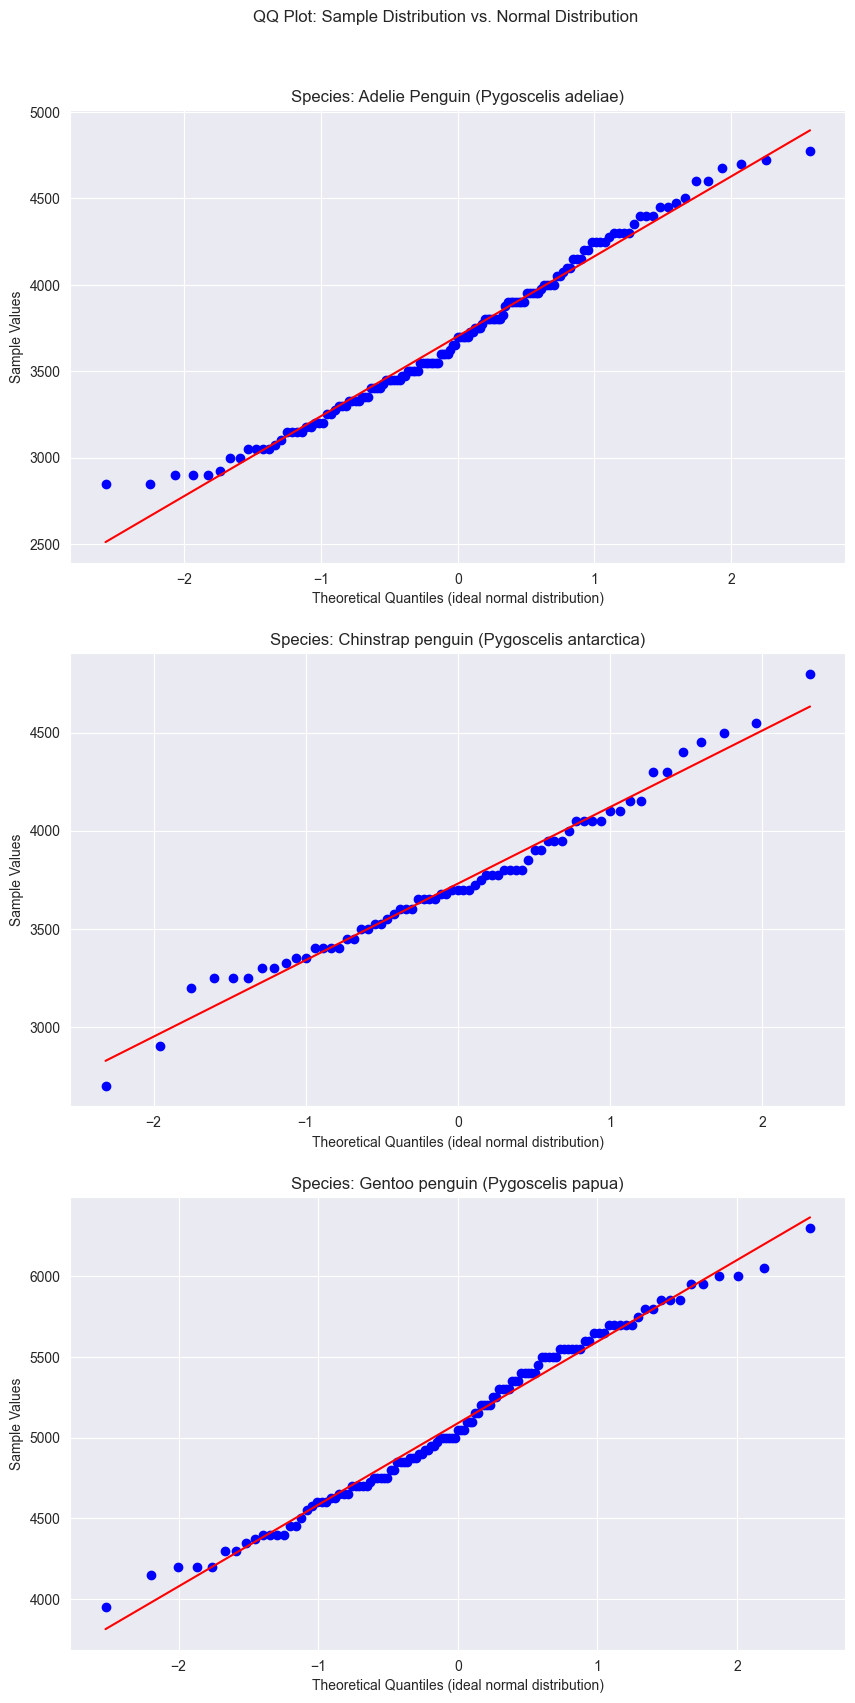

In [117]:
fig, axes = plt.subplots(df['Species'].nunique(), 1, figsize=(10,20))

for ax, (name, df_species) in zip(axes,df_by_species):
    stats.probplot(df_species['Body Mass (g)'], dist='norm', plot=ax)

    ax.set_title(f'Species: {name}')
    ax.set_xlabel('Theoretical Quantiles (ideal normal distribution)')
    ax.set_ylabel('Sample Values')

plt.suptitle("QQ Plot: Sample Distribution vs. Normal Distribution", y=0.93)
plt.show()



Based on visual methods, we can say that the distributions for each species are approximately normal.

2. Shapiro-Wilk test

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

We assume a confidence level of <b>0.90</b>. 

In [118]:
alpha = 0.05

In [119]:
for name, df_species in df_by_species:
    shapiro_test = stats.shapiro(df_species['Body Mass (g)'])

    print(f"Shapiro-Wilk test statistic for species {name}: {shapiro_test.statistic:.4f}")
    print(f"p-value for species {name}: {shapiro_test.pvalue:.4f}")

    if shapiro_test.pvalue > alpha:
        print("Fail to reject H0 – the distribution can be considered normal \n")
    else:
        print("Reject H0 – the distribution is not normal \n")

Shapiro-Wilk test statistic for species Adelie Penguin (Pygoscelis adeliae): 0.9813
p-value for species Adelie Penguin (Pygoscelis adeliae): 0.0533
Fail to reject H0 – the distribution can be considered normal 

Shapiro-Wilk test statistic for species Chinstrap penguin (Pygoscelis antarctica): 0.9832
p-value for species Chinstrap penguin (Pygoscelis antarctica): 0.5043
Fail to reject H0 – the distribution can be considered normal 

Shapiro-Wilk test statistic for species Gentoo penguin (Pygoscelis papua): 0.9854
p-value for species Gentoo penguin (Pygoscelis papua): 0.2285
Fail to reject H0 – the distribution can be considered normal 



After the statistical test, we can confirm our hypothesis that the distributions can be assumed to be normal.

## Bartlett’s Test for Homogeneity of Variances $\chi^2\$

**Bartlett’s test** is a statistical test used to determine whether **multiple groups have equal variances** (homoscedasticity).
It is often used as a **preliminary test before ANOVA**, which assumes equal variances across groups.

### Key Assumption

- A **necessary condition** for Bartlett’s test is that the **data in each group are normally distributed**.
  - If normality is violated, the test may produce misleading results.
  - For non-normal data, consider **Levene’s test** instead.

### Hypotheses

- $H_0$: All group variances are **equal** ($\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$)
- $H_1$: At least one group variance is **different**

### Test Statistic

The test statistic is based on the **logarithms of the sample variances**:

$$
\chi^2 = \frac{(N - k) \ln(S_p^2) - \sum_{i=1}^{k} (n_i - 1) \ln(S_i^2)}{1 + \frac{1}{3(k-1)} \left( \sum_{i=1}^{k} \frac{1}{n_i - 1} - \frac{1}{N - k} \right)}
$$

Where:

- $S_i^2$ – sample variance of group $i$
- $n_i$ – sample size of group $i$
- $k$ – number of groups
- $N$ – total number of observations ($N = \sum_{i=1}^{k} n_i$)
- $S_p^2$ – pooled variance, calculated as:

$$
S_p^2 = \frac{\sum_{i=1}^{k} (n_i - 1) S_i^2}{N - k}
$$

### Decision Rule

- Compute the $\chi^2$ statistic
- Compare with the **critical value from the chi-square distribution** with $k-1$ degrees of freedom, or check the **p-value**:

  - If $p \geq \alpha$, fail to reject $H_0$ → **variances are equal**
  - If $p < \alpha$, reject $H_0$ → **at least one variance differs**

### Notes

- Homogeneity of variances is a **key assumption for ANOVA** and other parametric tests.
- Because **normality is required**, it is common to check it first using tests like **Shapiro-Wilk**.

1. Bartlett test

- **H0**: all groups have the same variance.
- **HA**: at least one group has a different variance

In [120]:
species = [df_species['Body Mass (g)'] for name, df_species in df_by_species]

In [121]:
w, pvalue = stats.bartlett(*species)

if pvalue > alpha:
    print("Fail to reject H0 – the variances across all groups can be considered equal.\n")
else:
    print("Reject H0 – at least one group has a different variance.\n")

Fail to reject H0 – the variances across all groups can be considered equal.



<b> We assumed that our data have a normal distribution and satisfy the homogeneity of variances. We can now proceed with the ANOVA test. </b>

### ANOVA test

1. Generatre boxplots

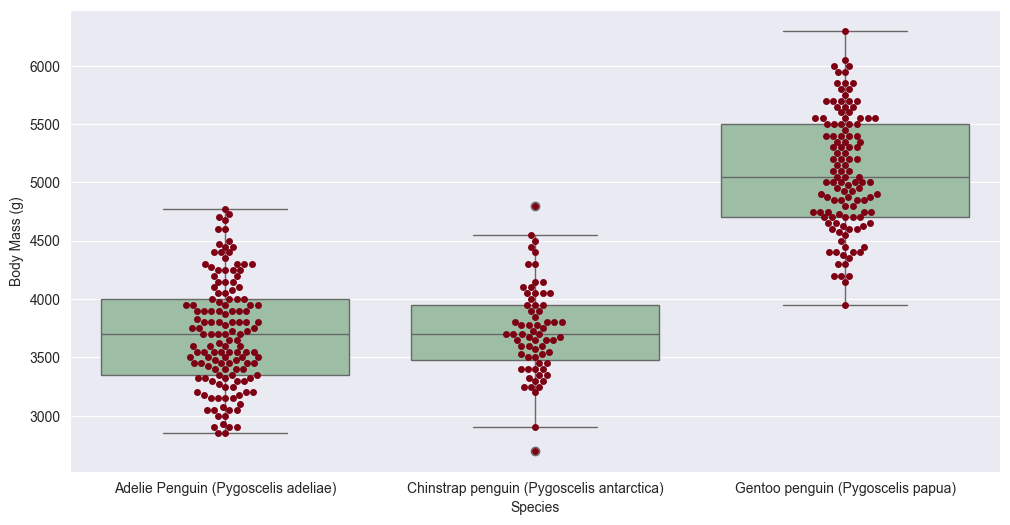

In [122]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(x='Species', y='Body Mass (g)', data=df, color='#99c2a2')
ax = sns.swarmplot(x="Species", y="Body Mass (g)", data=df, color='#7d0013')

From the chart, we can see that the species differ from each other. Gentoo penquin has the biggest average bodyu massnglish


2. ANOVA [bioinfokit]

In [123]:
df = df.rename(columns={'Body Mass (g)': 'Body_mass'})

In [124]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body_mass', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [125]:
df = df.rename(columns={'Body Mass (g)': 'Body_mass'})

res = stat()
res.anova_stat(df=df, res_var='Body_mass', anova_model='Body_mass ~ C(Species)')
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Species),2.0,1.432112e+08,7.160559e+07,335.292226,1.928559e-79
Residual,322.0,6.876688e+07,2.135617e+05,NaN,NaN


Differences between species are enormous compared to body mass differences among one species

<span style='color:red'> Reject H0 – At least one species has a different mean body mass. </span>

## Hypothesis Test #2 - $\chi^2$ Test of Independence

### Relationship Between Species and Islands (Categorical Variables)

The **Chi-square test of independence** is a statistical test used to determine whether **two categorical variables are independent** or whether there is a **relationship between them**.

The test is based on a **contingency table**, which shows the frequency distribution of the variables. It compares the **observed frequencies** with the **expected frequencies** that would occur if the variables were independent.

### Hypotheses

- $H_0$: The variables are **independent** (there is no association between them).
- $H_1$: The variables are **not independent** (there is an association between them).

### Expected Frequencies

The expected frequency for each cell in the contingency table is calculated as:

$$
E_{ij} = \frac{R_i \cdot C_j}{n}
$$

Where:

- $E_{ij}$ – expected frequency in cell $(i,j)$
- $R_i$ – total frequency of row $i$
- $C_j$ – total frequency of column $j$
- $n$ – total number of observations

### Test Statistic

The test statistic is calculated using the formula:

$$
\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

Where:

- $O_{ij}$ – observed frequency in cell $(i,j)$
- $E_{ij}$ – expected frequency in cell $(i,j)$

### Decision Rule

The calculated value of the statistic is compared with the **critical value from the chi-square distribution** with the following degrees of freedom:

$$
df = (r - 1)(c - 1)
$$

Where:

- $r$ – number of rows
- $c$ – number of columns

If the **p-value** is smaller than the chosen significance level $\alpha$, the null hypothesis is rejected.

### Assumptions

- The variables are **categorical**.
- Observations are **independent**.
- The data are presented as **frequencies** (counts), not percentages.
- The **expected frequency in each cell should generally be at least 5**.

### Interpretation

- If $H_0$ is rejected → there is evidence of an **association between the variables**.
- If $H_0$ is not rejected → there is **no evidence of a relationship** between the variables.

We will use the $\chi^2$ test of independence if the test assumptions are satisfied.

In [126]:
df['Species'].unique()

array(['Adelie Penguin (Pygoscelis adeliae)',
       'Chinstrap penguin (Pygoscelis antarctica)',
       'Gentoo penguin (Pygoscelis papua)'], dtype=object)

In [127]:
df['Island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

**Species:**  
- Adelie Penguin (Pygoscelis adeliae)
- Gentoo penguin (Pygoscelis papua)  
- Chinstrap penguin (Pygoscelis antarctica)  

**Isalnds:**  
- Torgersen
- Biscoe  
- Dream

**Assumptions:**  
1. Both features must be categorical.
2. No more than 20% of the expected counts in the contingency table should be less than 5, and no expected count should be less than 1.


- **H0**: The penguin species is independent of the island it inhabits.
- **HA**: The penguin species depends on the island it inhabits.

### Categorical features test

In [128]:
df['Species'].info()

<class 'pandas.core.series.Series'>
Index: 325 entries, 1 to 343
Series name: Species
Non-Null Count  Dtype 
--------------  ----- 
325 non-null    object
dtypes: object(1)
memory usage: 5.1+ KB


In [129]:
df['Species'].unique()

array(['Adelie Penguin (Pygoscelis adeliae)',
       'Chinstrap penguin (Pygoscelis antarctica)',
       'Gentoo penguin (Pygoscelis papua)'], dtype=object)

<b> Species feature is categorical - </b> <span  style="color: green;"> PASS  </span>

### Test of Expected Cell Counts

In [130]:
observed = pd.crosstab(df['Species'], df['Island'])
observed

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),44,52,43
Chinstrap penguin (Pygoscelis antarctica),0,67,0
Gentoo penguin (Pygoscelis papua),119,0,0


In [131]:
chi2_stat, p_val, dof, expected = stats.chi2_contingency(observed)

In [132]:
(expected == 0).any()

np.False_

In [133]:
total_cells = expected.size
cells_ge_5 = (expected >= 5).sum()
percent_ge_5 = (cells_ge_5 / total_cells) * 100

percent_ge_5

np.float64(100.0)

<b>More than 80% of expected samples are >=5 - </b> <span style="color:green"> PASS </span>


<b>There are no samples <1 - </b> <span style="color:green"> PASS </span>

In [134]:
df_expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
df_expected.round(2)

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),69.71,50.90,18.39
Chinstrap penguin (Pygoscelis antarctica),33.60,24.53,8.86
Gentoo penguin (Pygoscelis papua),59.68,43.57,15.74


In [135]:
print(f"Statistic: {chi2_stat:.4f}")
print(f"p (p-value): {p_val:.4f}")

Statistic: 276.6920
p (p-value): 0.0000


In [136]:
if p_val < alpha:
    print(f"p < {alpha}. We reject the null hypothesis (H0).")
    print("There is a statistically significant association between the variables.")
else:
    print(f"p >= {alpha}. There is no evidence to reject the null hypothesis (H0).")
    print("The variables appear to be independent of each other.")

p < 0.05. We reject the null hypothesis (H0).
There is a statistically significant association between the variables.


<span style='color:red'> Reject H0 – The penguin species depends on the island it inhabits.. </span>

## Correlation for Categorical Variables

### Relationship Between Species and Islands

### Jule’s Phi Coefficient (φ)

**Jule’s Phi coefficient** is a measure of association between **two binary (dichotomous) categorical variables**.
It is commonly used when the data can be represented in a **2 × 2 contingency table**.

The coefficient measures the **strength of the relationship** between two variables.
It is mathematically equivalent to the **Pearson correlation coefficient** calculated for binary variables.

### Contingency Table

|        | B = 1 | B = 0 |
|-------|-------|-------|
| A = 1 | a     | b     |
| A = 0 | c     | d     |

Where:

- $a$ – number of observations where $A=1$ and $B=1$
- $b$ – number of observations where $A=1$ and $B=0$
- $c$ – number of observations where $A=0$ and $B=1$
- $d$ – number of observations where $A=0$ and $B=0$

### Formula

The formula for Jule’s Phi coefficient is:

$$
\phi = \frac{ad - bc}{\sqrt{(a+b)(a+c)(b+d)(c+d)}}
$$

### Range of Values

The coefficient takes values in the range:

$$
-1 \leq \phi \leq 1
$$

### Interpretation

- $\phi = 0$ → no association between variables
- $\phi > 0$ → positive association
- $\phi < 0$ → negative association
- $|\phi|$ close to **1** → strong association
- $|\phi|$ close to **0** → weak association

### Notes

- The coefficient is **only appropriate for 2 × 2 contingency tables**.
- For larger contingency tables (e.g., $r \times c$), a generalization such as **Cramér’s V** is usually used.
- It can also be computed using the **chi-square statistic**:

$$
\phi = \sqrt{\frac{\chi^2}{n}}
$$`

Where:

- $\chi^2$ – chi-square statistic
- $n$ – total number of observations

In [137]:
cm = pd.crosstab(df['Species'], df['Island'])
cm

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),44,52,43
Chinstrap penguin (Pygoscelis antarctica),0,67,0
Gentoo penguin (Pygoscelis papua),119,0,0


In [138]:
n = cm.sum().sum()
n

np.int64(325)

In [139]:
chi2_stat

np.float64(276.6919567403251)

In [140]:
phi = np.sqrt(chi2_stat / n)
print(phi)

0.9226916423666728


There is a strong correlation between island and penguin species.

### Cramér’s V

**Cramér’s V** is a measure of association between **two categorical variables**.
It is based on the **chi-square statistic** and is used to measure the **strength of the relationship** in a **contingency table of any size** ($r \times c$).

It is a generalization of the **Phi coefficient**, which is limited to **2 × 2 tables**.

### Formula

Cramér’s V is defined as:

$$
V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}}
$$

Where:

- $\chi^2$ – chi-square statistic from the contingency table
- $n$ – total number of observations
- $r$ – number of rows in the table
- $c$ – number of columns in the table
- $\min(r-1, c-1)$ – the smaller value between $r-1$ and $c-1$

### Range of Values

The coefficient takes values in the range:

$$
0 \leq V \leq 1
$$

### Interpretation

- $V = 0$ → no association between variables
- $V$ close to **0** → weak association
- $V$ close to **1** → strong association

Unlike the Phi coefficient, **Cramér’s V cannot take negative values**, because it is based on the **chi-square statistic**, which is always non-negative.

### Notes

- It can be applied to **any contingency table size** ($2 \times 2$, $3 \times 4$, etc.).
- For **2 × 2 tables**, Cramér’s V is equivalent to the **Phi coefficient**.
- It measures only the **strength of association**, not the direction of the relationship.

In [141]:
k, r = cm.shape

In [142]:
m = min(k-1,r-1)
m

2

In [143]:
V = np.sqrt(chi2_stat/(n*(m-1)))
print(V)

0.9226916423666728


There is a strong correlation between island and penguin species.

### Pearson’s Contingency Coefficient (C)

**Pearson’s contingency coefficient (C)** is a measure of association between **two categorical variables** based on the **chi-square statistic** from a contingency table.

It is used to assess the **strength of the relationship** between variables in an **$r \times c$ contingency table**.

### Formula

The coefficient is defined as:

$$
C = \sqrt{\frac{\chi^2}{\chi^2 + n}}
$$

Where:

- $\chi^2$ – chi-square statistic from the contingency table
- $n$ – total number of observations

### Range of Values

The coefficient takes values in the range:

$$
0 \leq C < 1
$$

However, the maximum value of $C$ **depends on the size of the contingency table**, so it **never reaches 1**.

### Interpretation

- $C = 0$ → no association between variables
- larger values of $C$ → stronger association between variables

Because the upper limit depends on the table size, **Pearson’s contingency coefficient is less convenient for comparing associations across different tables**.

### Notes

- The coefficient is derived from the **chi-square statistic**.
- It can be applied to **contingency tables of any size**.
- Unlike some other measures, it **does not reach 1 even for perfect association**.
- For this reason, **Cramér’s V** is often preferred when comparing the strength of associations across different contingency tables.

In [144]:
C = np.sqrt(chi2_stat / (chi2_stat + n))
print(C)

0.6781271997655933


There is a strong correlation between island and penguin species.

## Correlation for Numerical Variables

### Relationship Between Body Mass (body_mass_g) and Flipper Length (flipper_length_mm)

### Pearson Correlation Coefficient

The **Pearson correlation coefficient** ($r$) is a measure of the **linear relationship** between two **continuous numerical variables**.
It quantifies both the **strength** and **direction** of the association.

### Formula

For two variables $X$ and $Y$ with $n$ observations:

$$
r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$

Where:

- $X_i$, $Y_i$ – individual observations
- $\bar{X}$, $\bar{Y}$ – sample means of $X$ and $Y$
- $n$ – number of observations

### Range of Values

$$
-1 \le r \le 1
$$

- $r = 1$ → perfect positive linear relationship
- $r = -1$ → perfect negative linear relationship
- $r = 0$ → no linear relationship

### Hypotheses (for significance testing)

- $H_0$: $r = 0$ → no linear correlation
- $H_1$: $r \ne 0$ → significant linear correlation

### Assumptions / Conditions Before Using Pearson Correlation

1. **Linearity** – the relationship between the variables should be approximately linear
2. **Normality** – both variables should be approximately normally distributed
   - Can be checked using tests like **Shapiro-Wilk**
3. **Homoscedasticity** – the variance of one variable should be roughly constant across the values of the other variable
4. **Independence of observations** – each observation is independent of the others
5. **No strong outliers** – extreme values can distort the correlation and lead to misleading results. Consider visualizing the data with a **scatter plot** before calculating the correlation.

<b> We will use Pearson’s Correlation Coefficient test (when assumptions meet) </b>

In [145]:
df['Flipper Length (mm)'].describe()

count    325.000000
mean     201.264615
std       13.964598
min      172.000000
25%      190.000000
50%      197.000000
75%      213.000000
max      231.000000
Name: Flipper Length (mm), dtype: float64

**Assumptions:**  
1. Observations in each sample are independent and distributed identically. 
2. Observations are normally distributed.
3. Similar variance between independent variables    

- **H0**: There is no correlation between the two variables.
- **HA**: There is a correlation between the two variables.

### Normality test

1. QQ plot check

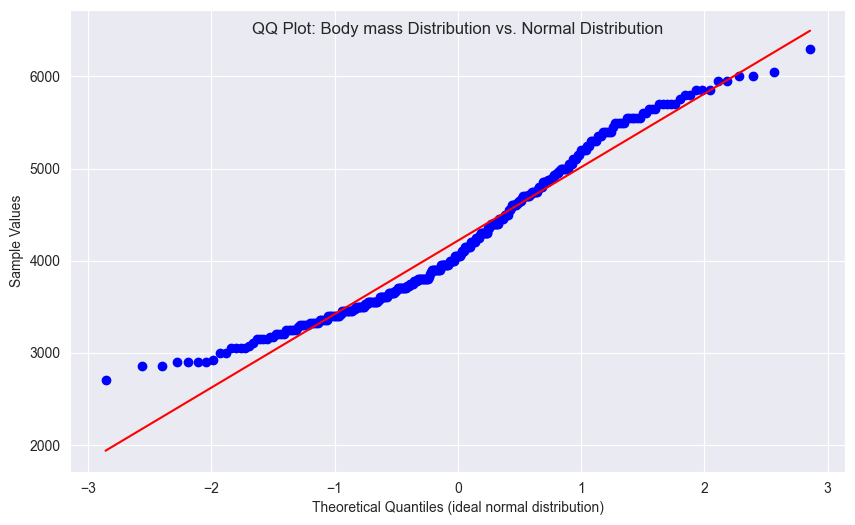

In [146]:
fig = plt.figure(figsize=(10,6))

stats.probplot(df['Body_mass'], dist='norm', plot=plt)

plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.title("QQ Plot: Body mass Distribution vs. Normal Distribution", y=0.93)
plt.show()

2. Shapiro-Wilk test

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

In [147]:
shapiro_test = stats.shapiro(df['Body_mass'])

print(f"Shapiro-Wilk test statistic for body mass: {shapiro_test.statistic:.4f}")
print(f"p-value for body mass {name}: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue > alpha:
    print("Fail to reject H0 – the distribution can be considered normal \n")
else:
    print("Reject H0 – the distribution is not normal \n")

Shapiro-Wilk test statistic for body mass: 0.9596
p-value for body mass Gentoo penguin (Pygoscelis papua): 0.0000
Reject H0 – the distribution is not normal 



The distribution is not normal, so we will use **Spearman’s Rank Correlation** instead of Pearson’s correlation.

### Spearman’s Rank Correlation Coefficient

**Spearman’s rank correlation coefficient** ($\rho$ or $r_s$) is a **non-parametric measure** of the **monotonic relationship** between two variables.
It is used when the **assumptions of Pearson correlation** (normality, linearity) are **not met**, or when dealing with **ordinal data**.

### Idea

- Instead of using raw data values, Spearman’s correlation uses **ranks** of the data.
- It measures whether **as one variable increases, the other tends to increase or decrease**, without assuming linearity.

### Formula

For a sample of size $n$, with ranks $R(X_i)$ and $R(Y_i)$:

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

Where:

- $d_i = R(X_i) - R(Y_i)$ – difference between ranks of the $i$-th observation
- $n$ – number of observations

### Range of Values

$$
-1 \le \rho \le 1
$$

- $\rho = 1$ → perfect increasing monotonic relationship
- $\rho = -1$ → perfect decreasing monotonic relationship
- $\rho = 0$ → no monotonic relationship

### Hypotheses (for significance testing)

- $H_0$: $\rho = 0$ → no monotonic association
- $H_1$: $\rho \ne 0$ → significant monotonic association

### Assumptions / Conditions

1. **Variables can be ordinal, interval, or ratio**
2. **Observations are independent**
3. **Relationship is monotonic**, not necessarily linear
4. **Outliers affect the coefficient less than Pearson’s correlation**, but extreme ranks can still have some impact

### Notes

- Spearman’s correlation is **robust to non-normal data**.
- Often used when data contain **outliers** or when testing **ranked/ordinal variables**.
- Can be computed using either **ranks** or **a formula based on the difference of ranks** as shown above.

In [148]:
stat, p = stats.spearmanr(df['Body_mass'], df['Flipper Length (mm)'])

In [149]:
print('stat={0:.3g}, p={0:.3f}'.format(stat, p))
if p > alpha:
    print('Fail to reject H0 – There is propably no correlation between the two variables.\n')
else:
    print('Reject H0 - There is a correlation between the two variables.')

stat=0.849, p=0.849
Reject H0 - There is a correlation between the two variables.


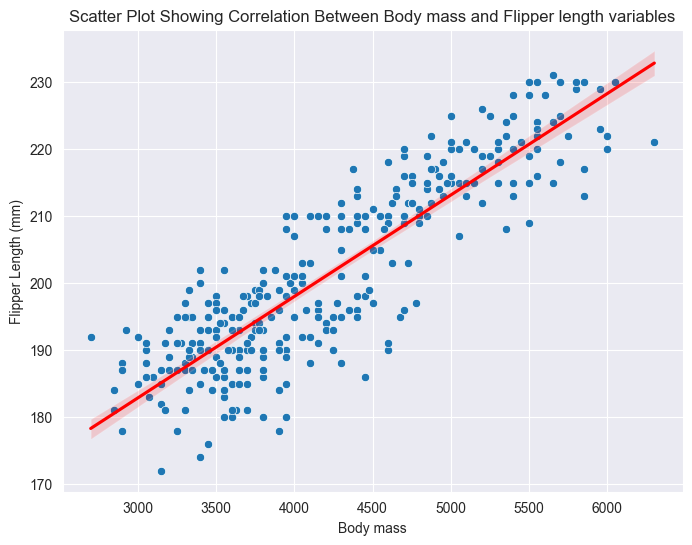

In [150]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Body_mass'], y=df['Flipper Length (mm)'])
sns.regplot(x=df['Body_mass'], y=df['Flipper Length (mm)'], scatter=False, color='red') 
plt.xlabel("Body mass")
plt.ylabel("Flipper Length (mm)")
plt.title("Scatter Plot Showing Correlation Between Body mass and Flipper length variables")
plt.show()

<b style='color:green'> There is strong correlation between this two variables </b>